## Setup

In [1]:
from pathlib import Path

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:

from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from sktime.regression.distance_based import KNeighborsTimeSeriesRegressor
from sktime.classification.model_selection import TSCGridSearchCV
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.preprocessing import StandardScaler

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = (train[[str(i) for i in range(100)]]
           .reset_index()
           .melt(id_vars='id', var_name='time')
           )
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])

## Shape based classification and regression with KNN

### Action

In [6]:
train_y = train['action']
train_y.shape

(850,)

In [7]:
pipeline = TabularToSeriesAdaptor(StandardScaler(), fit_in_transform=True) * KNeighborsTimeSeriesClassifier()
pipeline

ClassifierPipeline(classifier=KNeighborsTimeSeriesClassifier(),
                   transformers=[TabularToSeriesAdaptor(fit_in_transform=True,
                                                        transformer=StandardScaler())])

In [8]:
ks = np.arange(1, 31, 2)

param_grid = [
    {'classifier__distance': ('dtw',),
    'classifier__n_neighbors': ks,
    'classifier__distance_params__window': (.005, .01),
    'classifier__weights': ('uniform', 'distance')
    },
    {'classifier__distance': ('euclidean',),
     'classifier__n_neighbors': ks,
     'classifier__weights': ('uniform', 'distance')
     }
]

`TSCGridSearchCV` already uses stratified kfold cross-validation if the target is binary or multiclass. It is also impossible to use `InstanceSplitter` properly.

In [9]:
grid = TSCGridSearchCV(
    pipeline, param_grid=param_grid,
    scoring='f1', n_jobs=-1, verbose=2,
)

In [10]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  10.9s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.1s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.1s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=distance; total time=  11.1s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.1s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.1s
[CV] END classifier

TSCGridSearchCV(estimator=ClassifierPipeline(classifier=KNeighborsTimeSeriesClassifier(),
                                             transformers=[TabularToSeriesAdaptor(fit_in_transform=True,
                                                                                  transformer=StandardScaler())]),
                n_jobs=-1,
                param_grid=[{'classifier__distance': ('dtw',),
                             'classifier__distance_params__window': (0.005,
                                                                     0.01),
                             'classifier__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]),
                             'classifier__weights': ('uniform', 'distance')},
                            {'classifier__distance': ('euclidean',),
                             'classifier__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]),
                             'classifier__weights': ('uniform', 'distance')}],
                scoring='f1', verbose=2)

In [11]:
print(grid.best_score_)
print(grid.best_params_)

0.5671747300654532
{'classifier__distance': 'dtw', 'classifier__distance_params__window': 0.005, 'classifier__n_neighbors': np.int64(23), 'classifier__weights': 'uniform'}


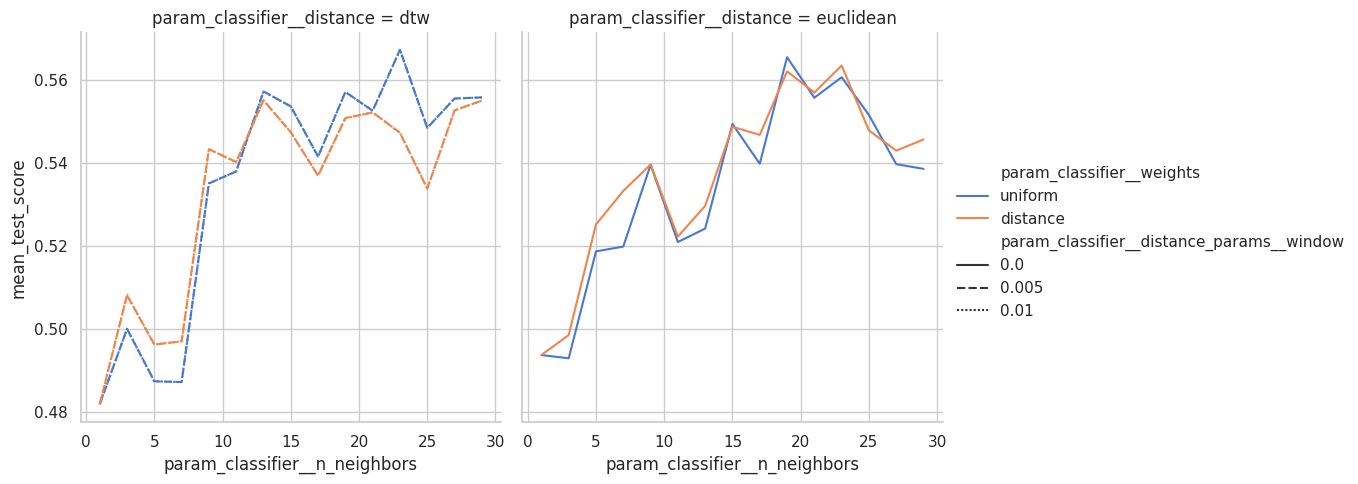

In [12]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_classifier__n_neighbors', y='mean_test_score',
            style='param_classifier__distance_params__window',
            hue='param_classifier__weights', col='param_classifier__distance',
            kind='line')

Generally speaking, performance is better when using Dynamic Time Warping as distance function. Experimenting with different values for the Sakoe Chiba Band window size, we noticed that no noticeable impact on the performance of the classifier. Since the principal computational cost of the classifier is in the computation of distances, it makes sense to use the smallest window.

In [13]:
action_shape_knn = grid.best_estimator_

### Rating Category

In [14]:
train_y = train['rating_category']

In [15]:
# Use macro f1 for multiclass classification
grid.scoring = 'f1_macro'

In [16]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.4s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.5s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.6s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.8s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=distance; total time=  11.7s
[CV] END classifier__distance=dtw, classifier__distance_params__window=0.005, classifier__n_neighbors=1, classifier__weights=uniform; total time=  11.9s
[CV] END classifier

TSCGridSearchCV(estimator=ClassifierPipeline(classifier=KNeighborsTimeSeriesClassifier(),
                                             transformers=[TabularToSeriesAdaptor(fit_in_transform=True,
                                                                                  transformer=StandardScaler())]),
                n_jobs=-1,
                param_grid=[{'classifier__distance': ('dtw',),
                             'classifier__distance_params__window': (0.005,
                                                                     0.01),
                             'classifier__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]),
                             'classifier__weights': ('uniform', 'distance')},
                            {'classifier__distance': ('euclidean',),
                             'classifier__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]),
                             'classifier__weights': ('uniform', 'distance')}],
                scoring='f1_macro', verbose=2)

In [17]:
print(grid.best_score_)
print(grid.best_params_)

0.27895288528960366
{'classifier__distance': 'dtw', 'classifier__distance_params__window': 0.005, 'classifier__n_neighbors': np.int64(5), 'classifier__weights': 'distance'}


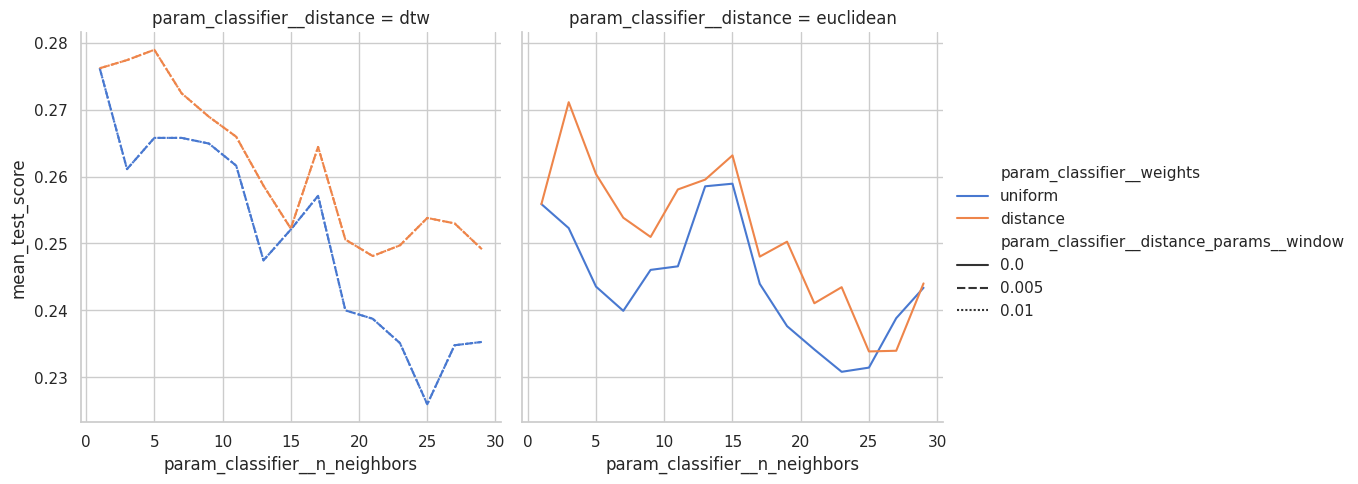

In [18]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_classifier__n_neighbors', y='mean_test_score',
            style='param_classifier__distance_params__window',
            hue='param_classifier__weights', col='param_classifier__distance',
            kind='line')

In [19]:
rating_shape_knn = grid.best_estimator_

### Rating (regression)

In [20]:
param_grid = [
    {'regressor__distance': ('dtw',),
    'regressor__n_neighbors': ks,
    'regressor__distance_params__window': (.005, .01),
    'regressor__weights': ('uniform', 'distance')
    },
    {'regressor__distance': ('euclidean',),
     'regressor__n_neighbors': ks,
     'regressor__weights': ('uniform', 'distance')
     }
]

In [21]:
pipeline = TabularToSeriesAdaptor(StandardScaler(), fit_in_transform=True) * KNeighborsTimeSeriesRegressor()

In [22]:
train_y = train['rating']
grid = TSCGridSearchCV(
    pipeline, param_grid=param_grid,
    scoring='neg_mean_squared_error', n_jobs=-1, verbose=2,
)

In [23]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV] END regressor__distance=dtw, regressor__distance_params__window=0.005, regressor__n_neighbors=1, regressor__weights=uniform; total time=  11.6s
[CV] END regressor__distance=dtw, regressor__distance_params__window=0.005, regressor__n_neighbors=1, regressor__weights=uniform; total time=  11.6s
[CV] END regressor__distance=dtw, regressor__distance_params__window=0.005, regressor__n_neighbors=1, regressor__weights=uniform; total time=  11.7s
[CV] END regressor__distance=dtw, regressor__distance_params__window=0.005, regressor__n_neighbors=1, regressor__weights=distance; total time=  11.6s
[CV] END regressor__distance=dtw, regressor__distance_params__window=0.005, regressor__n_neighbors=1, regressor__weights=distance; total time=  11.6s
[CV] END regressor__distance=dtw, regressor__distance_params__window=0.005, regressor__n_neighbors=1, regressor__weights=distance; total time=  11.7s
[CV] END regressor__distance=dtw, regress

TSCGridSearchCV(estimator=RegressorPipeline(regressor=KNeighborsTimeSeriesRegressor(),
                                            transformers=[TabularToSeriesAdaptor(fit_in_transform=True,
                                                                                 transformer=StandardScaler())]),
                n_jobs=-1,
                param_grid=[{'regressor__distance': ('dtw',),
                             'regressor__distance_params__window': (0.005,
                                                                    0.01),
                             'regressor__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]),
                             'regressor__weights': ('uniform', 'distance')},
                            {'regressor__distance': ('euclidean',),
                             'regressor__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]),
                             'regressor__weights': ('uniform', 'distance')}],
                scoring='neg_mean_squared_error', verbose=2)

In [24]:
print(grid.best_score_)
print(grid.best_params_)

-0.6494542143901184
{'regressor__distance': 'dtw', 'regressor__distance_params__window': 0.005, 'regressor__n_neighbors': np.int64(19), 'regressor__weights': 'distance'}


In [25]:
train['rating'].var()

np.float64(0.8154520889627935)

Sum of square error is in fact smaller that the sample variance of the target variable, so the regressor is doing better than predicting the mean.

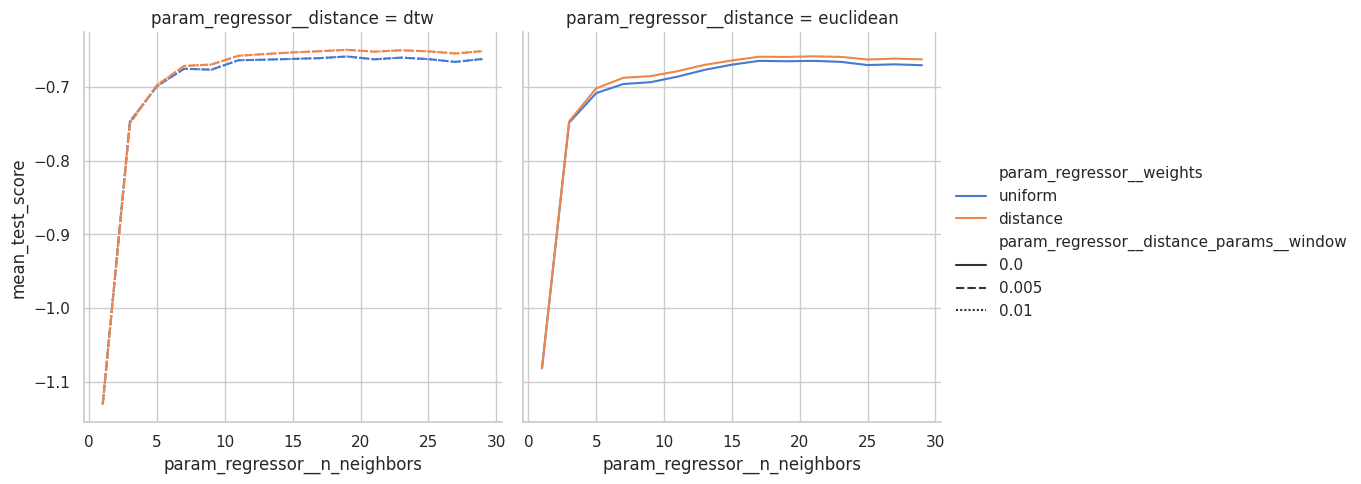

In [26]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_regressor__n_neighbors', y='mean_test_score',
            style='param_regressor__distance_params__window',
            hue='param_regressor__weights', col='param_regressor__distance',
            kind='line')

In [27]:
regressor_shape_knn = grid.best_estimator_

## Structure based classification and regression with knn

In [28]:
import pycatch22
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [29]:
result = pycatch22.catch22_all(train_X.loc[train.index[0]].values, catch24=True, short_names=True)
columns = result['short_names']

In [30]:
%%time
data = []
for idx in train.index:
    values = pycatch22.catch22_all(train_X.loc[idx].values, catch24=True)['values']
    data.append(values)
train_c22 = pd.DataFrame(data, columns=columns)
train_c22.index = train.index

CPU times: user 3.17 s, sys: 3.35 ms, total: 3.18 s
Wall time: 3.18 s


In [31]:
train_c22.head()

,mode_5,mode_10,acf_timescale,acf_first_min,ami2,trev,high_fluctuation,stretch_high,transition_matrix,periodicity,...,outlier_timing_neg,centroid_freq,stretch_decreasing,entropy_pairs,rs_range,dfa,low_freq_power,forecast_error,mean,SD
id,,,,,,,,,,,,,,,,,,,,,
tt10855768,-0.333098,-0.569656,3.292878,9,0.231946,-0.049935,0.767677,8.0,0.062500,13,...,0.550,0.817875,12.0,1.717638,0.314286,0.314286,0.392699,0.585646,640039.02,7.741079e+05
tt3766354,-0.204680,-0.447203,5.038619,10,0.384456,-0.035084,0.676768,20.0,0.074074,13,...,0.480,0.855605,10.0,1.544890,0.171429,0.600000,0.147262,0.370692,1975049.87,2.740085e+06
tt6791096,-0.235415,-0.476199,4.240450,9,0.381551,-0.037754,0.535354,20.0,0.074074,13,...,0.475,0.845503,12.0,1.499035,0.171429,0.600000,0.196350,0.443455,947198.80,1.281488e+06
tt1821549,-0.968873,-0.759462,3.452775,8,0.382275,0.029799,0.787879,18.0,0.002604,14,...,-0.550,0.877449,7.0,1.670886,0.828571,0.742857,0.392699,0.713396,131952.38,8.647096e+04
tt7144666,-0.305268,-0.580867,5.878877,9,0.412512,-0.022879,0.676768,25.0,0.074074,14,...,0.555,0.843426,6.0,1.452820,0.171429,0.600000,0.098175,0.338991,1710723.00,1.832369e+06


In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

### Action

In [33]:
param_grid = {'clf__metric': ('euclidean', 'manhattan'),
    'clf__n_neighbors': ks,
    'clf__weights': ('uniform', 'distance')
    }

In [34]:
train_y = train['action']

In [35]:
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)

In [36]:
%%time
grid.fit(train_c22, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.1s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'clf__metric': ('euclidean', ...), 'clf__n_neighbors': array([ 1, 3..., 25, 27, 29]), 'clf__weights': ('uniform', ...)}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,copy,True


In [37]:
print(grid.best_score_)
print(grid.best_params_)

0.5760896097037496
{'clf__metric': 'manhattan', 'clf__n_neighbors': np.int64(19), 'clf__weights': 'distance'}


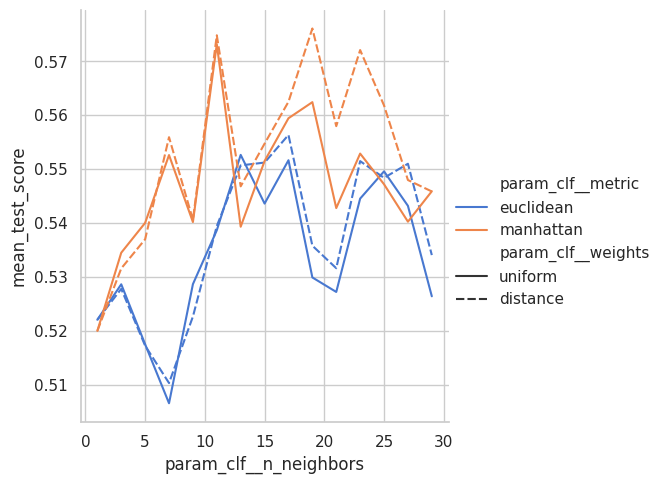

In [38]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_clf__n_neighbors', y='mean_test_score',
            hue='param_clf__metric',
            style='param_clf__weights',
            kind='line')

In [39]:
action_feat_knn = grid.best_estimator_

### Rating Category

In [40]:
train_y = train['rating_category']
grid.scoring = 'f1_macro'

In [41]:
%%time
grid.fit(train_c22, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s

[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=uniform; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV] END clf__metric=euclidean, clf__n_neighbors=1, clf__weights=distance; total time=   0.0s
[CV

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'clf__metric': ('euclidean', ...), 'clf__n_neighbors': array([ 1, 3..., 25, 27, 29]), 'clf__weights': ('uniform', ...)}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,copy,True


In [42]:
print(grid.best_score_)
print(grid.best_params_)

0.2994307867524203
{'clf__metric': 'euclidean', 'clf__n_neighbors': np.int64(7), 'clf__weights': 'uniform'}


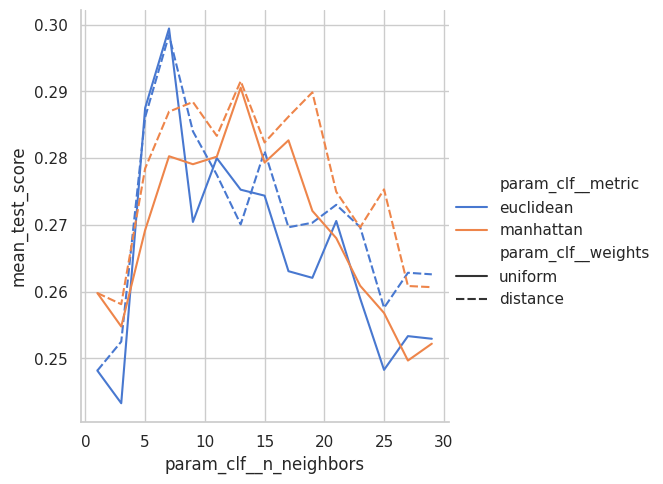

In [43]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_clf__n_neighbors', y='mean_test_score',
            hue='param_clf__metric',
            style='param_clf__weights',
            kind='line')

In [44]:
rating_feat_knn = grid.best_estimator_

### Rating (regression)

In [45]:
train_y = train['rating']

In [46]:
param_grid = {'regressor__metric': ('euclidean', 'manhattan'),
    'regressor__n_neighbors': ks,
    'regressor__weights': ('uniform', 'distance')
    }

In [47]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

grid = GridSearchCV(
    pipeline, param_grid=param_grid, n_jobs=-1, verbose=2,
    scoring='neg_mean_squared_error'
)

In [48]:
%%time
grid.fit(train_c22, train_y)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.0s
[CV] END regressor__metric=euclidean, regressor

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__metric': ('euclidean', ...), 'regressor__n_neighbors': array([ 1, 3..., 25, 27, 29]), 'regressor__weights': ('uniform', ...)}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [49]:
print(grid.best_score_)
print(grid.best_params_)

-0.5983278606619804
{'regressor__metric': 'manhattan', 'regressor__n_neighbors': np.int64(25), 'regressor__weights': 'distance'}


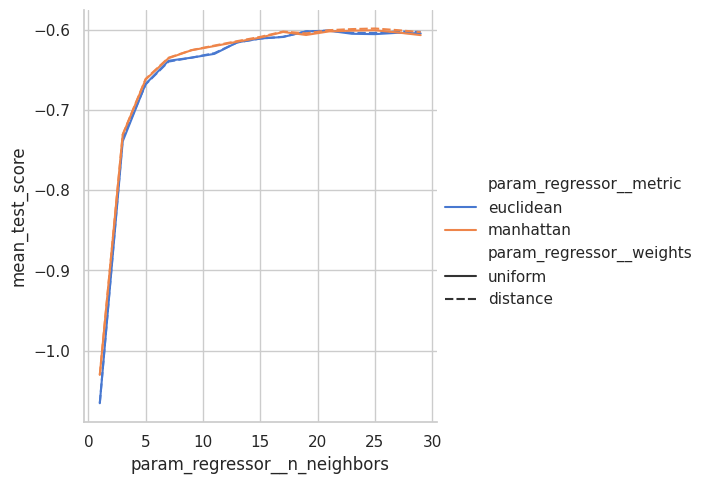

In [50]:
results = pd.DataFrame(grid.cv_results_)
results.fillna(0, inplace=True)
sns.relplot(results, x='param_regressor__n_neighbors', y='mean_test_score',
            style='param_regressor__weights', hue='param_regressor__metric',
            kind='line')

In [51]:
regressor_feat_knn = grid.best_estimator_

## Analysis and testing

We obtained better performances on all tasks using catch22 features instead of computing distances among raw time series.
We test only the best model for each task.

In [52]:
from sklearn.metrics import (PrecisionRecallDisplay,
                             ConfusionMatrixDisplay,
                             classification_report,
                             r2_score,
                             mean_squared_error)
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt

In [53]:
test = pd.read_csv(data_dir / 'test_ts.csv', index_col='id')
test['action'] = test['genre'].map(lambda x: 'Action' in x)
test_X = (test[[str(i) for i in range(100)]]
          .reset_index()
          .melt(id_vars='id', var_name='time')
)
test_X['time'] = test_X['time'].astype(int)
test_X = test_X.set_index(['id', 'time'])

In [54]:
%%time
data = []
for idx in test.index:
    values = pycatch22.catch22_all(test_X.loc[idx].values, catch24=True)['values']
    data.append(values)
test_c22 = pd.DataFrame(data, columns=columns)
test_c22.index = test.index

CPU times: user 969 ms, sys: 1.53 ms, total: 970 ms
Wall time: 968 ms


In [55]:
test_c22.head()

,mode_5,mode_10,acf_timescale,acf_first_min,ami2,trev,high_fluctuation,stretch_high,transition_matrix,periodicity,...,outlier_timing_neg,centroid_freq,stretch_decreasing,entropy_pairs,rs_range,dfa,low_freq_power,forecast_error,mean,SD
id,,,,,,,,,,,,,,,,,,,,,
tt4648786,-0.316525,-0.552612,4.523012,9,0.377360,-0.036620,0.616162,23.0,0.074074,13,...,0.51,0.862400,11.0,1.397202,0.171429,0.600000,0.098175,0.479744,829395.10,9.717637e+05
tt5776858,-0.560396,-0.767789,3.941483,7,0.478162,0.024731,0.646465,15.0,0.062500,14,...,-0.57,0.880164,10.0,1.531152,0.200000,0.657143,0.098175,0.662818,343477.84,3.260342e+05
tt21692408,-0.231879,-0.480891,3.932448,9,0.337966,-0.052011,0.656566,20.0,0.062500,13,...,0.55,0.861115,13.0,1.544890,0.171429,0.600000,0.196350,0.475692,3593529.81,4.531707e+06
tt2322441,0.084228,-0.191224,3.749193,9,0.229085,-0.068691,0.363636,20.0,0.074074,13,...,0.39,0.836215,9.0,1.397202,0.200000,0.600000,0.245437,0.413299,3166595.06,6.660734e+06
tt4302938,-0.381819,-0.600907,3.984079,8,0.310620,-0.053275,0.606061,11.0,0.062500,14,...,0.50,0.880364,12.0,1.617849,0.171429,0.600000,0.245437,0.531615,927595.39,1.097596e+06


In [56]:
true_action = test['action']
true_rating_cat = test['rating_category']
true_rating = test['rating']

### Action movies

In [57]:
pred_action = action_feat_knn.predict(test_c22)

In [58]:
print(classification_report(y_true=true_action, y_pred=pred_action))

              precision    recall  f1-score   support

       False       0.79      0.85      0.82       195
        True       0.60      0.49      0.54        89

    accuracy                           0.74       284
   macro avg       0.69      0.67      0.68       284
weighted avg       0.73      0.74      0.73       284



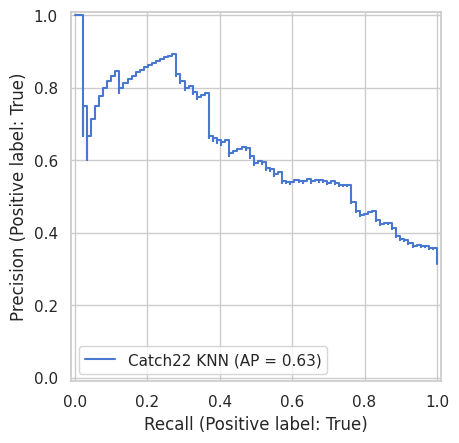

In [59]:
PrecisionRecallDisplay.from_estimator(action_feat_knn, test_c22, true_action, name='Catch22 KNN')

Looks like there are some high ranking false positives.

In [60]:
probs = action_feat_knn.predict_proba(test_c22)
results = pd.DataFrame(probs)
results['true'] = np.array(true_action)
results['pred'] = action_feat_knn.predict(test_c22)
high_rank_fp = results[~results['true']].sort_values(1, ascending=False).head(2).index

In [61]:
test.iloc[high_rank_fp, :]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,...,91,92,93,94,95,96,97,98,99,action
id,,,,,,,,,,,,,,,,,,,,,
tt2771200,Beauty and the Beast,2017,129,350898,US,True,16.0,81.0,7.1,"['Adventure', 'Family', 'Fantasy']",...,2043776.0,1193729.0,483200.0,591081.0,699791.0,582849.0,474904.0,471763.0,467892.0,False
tt1396484,It,2017,135,653607,"US,CA",True,12.0,49.0,7.3,['Horror'],...,838768.0,523413.0,293868.0,317557.0,344482.0,305812.0,276823.0,270970.0,263750.0,False


Both of these were highly anticipated reboots of popular products. It isn't at all surprising that they share similar traits with action blockbusters like 'Mad Max' and Marvel movies.

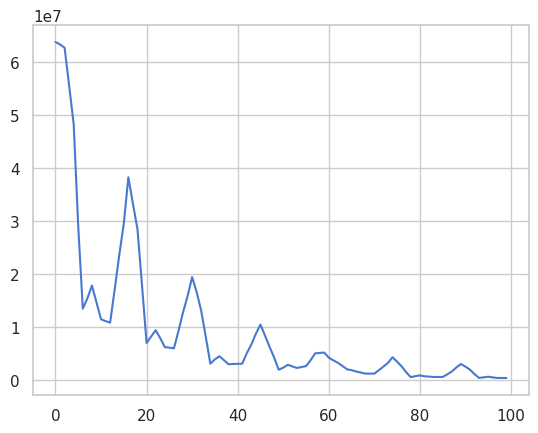

In [62]:
plt.plot(test_X.loc['tt2771200'])

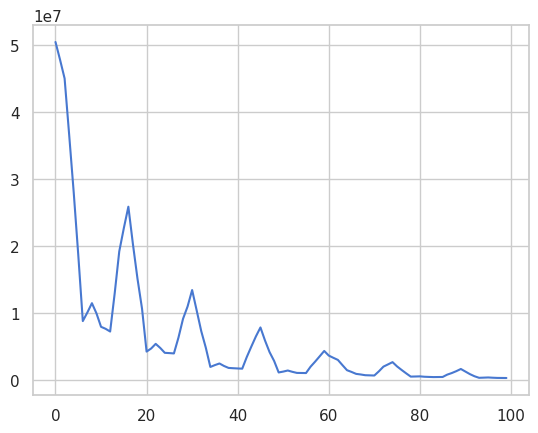

In [63]:
plt.plot(test_X.loc['tt1396484'])

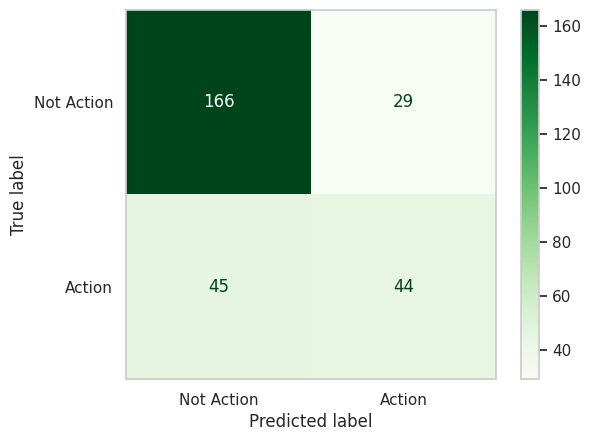

In [64]:
g = ConfusionMatrixDisplay.from_predictions(y_true=true_action, y_pred=pred_action, cmap='Greens', display_labels=('Not Action', 'Action'))
g.ax_.grid(False)

In [65]:
dummy = DummyClassifier(strategy='stratified')
dummy.fit(train_c22, train['action'])
dummy_action = dummy.predict(test_c22)
print(classification_report(y_true=true_action, y_pred=dummy_action))


              precision    recall  f1-score   support

       False       0.69      0.69      0.69       195
        True       0.33      0.34      0.33        89

    accuracy                           0.58       284
   macro avg       0.51      0.51      0.51       284
weighted avg       0.58      0.58      0.58       284



Performance exceeeds that of a Dummy Classifier.

### Rating

In [66]:
pred_rating_cat = rating_feat_knn.predict(test_c22)

In [67]:
print(classification_report(y_true=true_rating_cat, y_pred=pred_rating_cat))

              precision    recall  f1-score   support

        High       0.61      0.62      0.62        95
         Low       0.00      0.00      0.00         2
      Medium       0.44      0.62      0.52        96
 Medium High       0.24      0.15      0.18        61
  Medium Low       0.43      0.20      0.27        30

    accuracy                           0.47       284
   macro avg       0.34      0.32      0.32       284
weighted avg       0.45      0.47      0.45       284



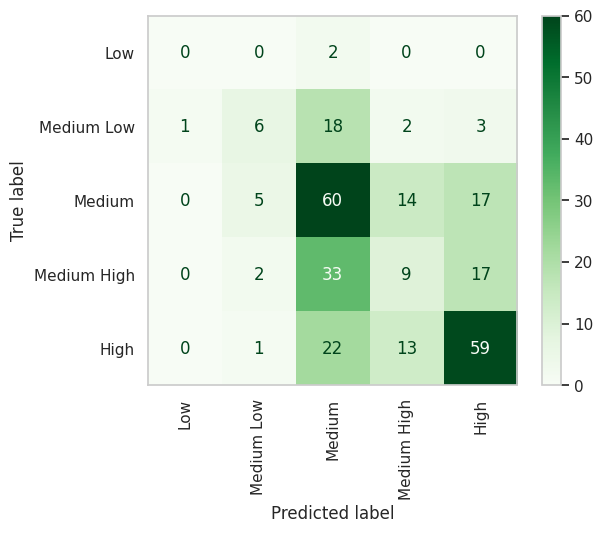

In [68]:
g = ConfusionMatrixDisplay.from_predictions(y_true=true_rating_cat, y_pred=pred_rating_cat, cmap='Greens',
                                            labels=['Low', 'Medium Low', 'Medium', 'Medium High', 'High'],
                                            xticks_rotation='vertical')
g.ax_.grid(False)

In [69]:
dummy = DummyClassifier(strategy='stratified')
dummy.fit(train_c22, train['rating_category'])
dummy_action = dummy.predict(test_c22)
print(classification_report(y_true=true_rating_cat, y_pred=dummy_action))

              precision    recall  f1-score   support

        High       0.35      0.41      0.38        95
         Low       0.00      0.00      0.00         2
      Medium       0.29      0.29      0.29        96
 Medium High       0.17      0.13      0.15        61
  Medium Low       0.16      0.13      0.15        30

    accuracy                           0.28       284
   macro avg       0.19      0.19      0.19       284
weighted avg       0.27      0.28      0.27       284



Performance exceeds that of a Dummy Classifier.

### Rating (regression)

In [70]:
pred_rating = regressor_feat_knn.predict(test_c22)
print("Mean squared error:", mean_squared_error(y_true=true_rating, y_pred=pred_rating))
print("R2 score:", r2_score(y_true=true_rating, y_pred=pred_rating))

Mean squared error: 0.5407358215687142
R2 score: 0.31966989897833764


In [71]:
corr = pearsonr(pred_rating, true_rating)
corr

PearsonRResult(statistic=np.float64(0.5766711646839113), pvalue=np.float64(1.4307401561680385e-26))

Text(4.5, 8.5, 'Pearson R:0.58 (p value: 0.00)')

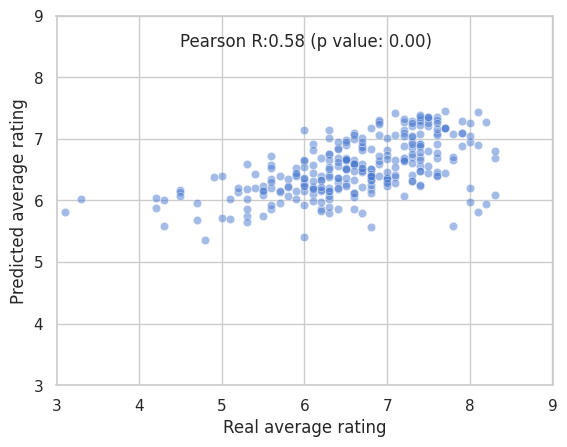

In [72]:
sns.scatterplot(x=true_rating, y=pred_rating, alpha=.5)
plt.xlim((3, 9))
plt.ylim((3, 9))
plt.xlabel("Real average rating")
plt.ylabel("Predicted average rating")
plt.text(4.5, 8.5, f"Pearson R:{corr.correlation:.2f} (p value: {corr.pvalue:.2f})")

Even though predicted values are squeezed towards the mean, real and predicted values are still moderately positively correlated (this result is statistically significant).